In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


### Reading and Cleaning data

In [19]:
r_df = pd.read_csv(r'movie_reviews\user_reviews.csv',)
r_df = r_df.drop(columns=['Unnamed: 0'])
r_df.head(10)

,User,The Net,Happily N'Ever After,Tomorrowland,American Hero,Das Boot,Final Destination 3,Licence to Kill,The Hundred-Foot Journey,The Matrix,...,The Martian,Micmacs,Solomon and Sheba,In the Company of Men,Silent House,Big Fish,Get Real,Trading Places,DOA: Dead or Alive,Hey Arnold! The Movie
0,Vincent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Edgar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Addilyn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Marlee,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Javier,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Marcus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Mary,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Rosalie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Giovanni,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Kennedi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0


In [20]:
g_df = pd.read_csv(r'movie_reviews\movie_genres.csv')
g_df = g_df.drop(columns=['Unnamed: 0'])
g_df.head()

,movie_title,genre_action,genre_adventure,genre_animation,genre_biography,genre_comedy,genre_crime,genre_documentary,genre_drama,genre_family,...,genre_mystery,genre_news,genre_reality-tv,genre_romance,genre_sci-fi,genre_short,genre_sport,genre_thriller,genre_war,genre_western
0,The Net,1,0,0,0,0,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
1,Happily N'Ever After,0,1,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,Tomorrowland,1,1,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,0
3,American Hero,1,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,Das Boot,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,1,0


There are multiple movie titles that has a comma in the name ("Peace, Propaganda & the Promised Land", "Gandhi, My Father"), which would read incorrectly as a comma seperated data. However the data reads correcly anyways, which might seem unlogical. Taking a closer look at the names with commas are enclosed in "quotes" thus reading the file as a comma seperated file works correcly. The other names are not enclosed in quotes since they don't need to. 

### Exploratory Data Analysis

Sparsity: 0.986


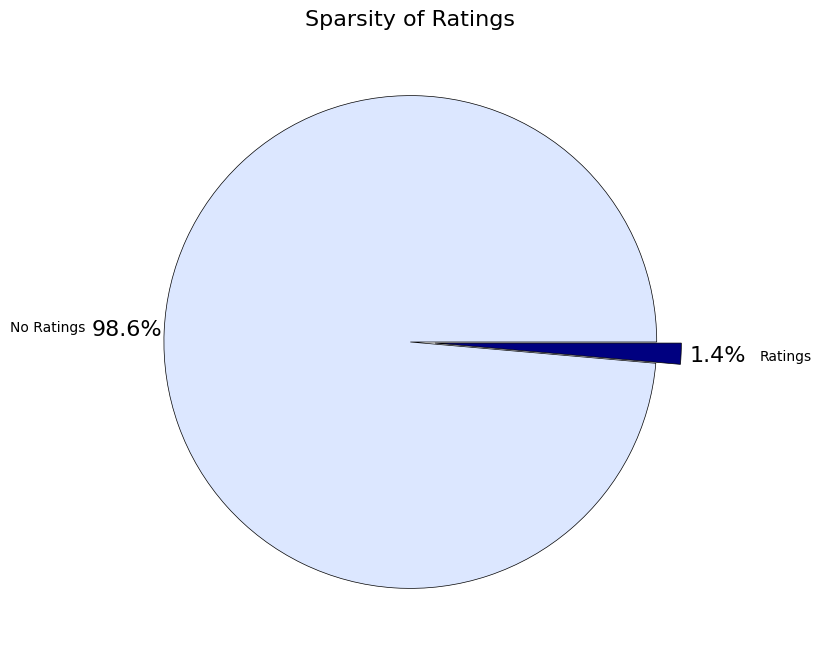

In [21]:
# Calculate sparsity
user_rating_matrix = r_df.drop(columns='User').values
total_elements = user_rating_matrix.size
zero_ratings = np.sum(user_rating_matrix == 0)
sparsity = zero_ratings / total_elements
print(f"Sparsity: {sparsity:.3f}")

# Plot
labels = ['No Ratings', 'Ratings']
sizes = [zero_ratings, total_elements - zero_ratings]

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=0,
    colors=['#dce7ff', '#000080'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
    explode=[0, 0.1],        # Slightly pull out the small slice
    pctdistance=1.15,         # Move percentage text away from center
    labeldistance=1.32        # Move labels further out
)

for autotext in autotexts:
    autotext.set_fontsize(16)

plt.title('Sparsity of Ratings', fontsize=16)
plt.show()

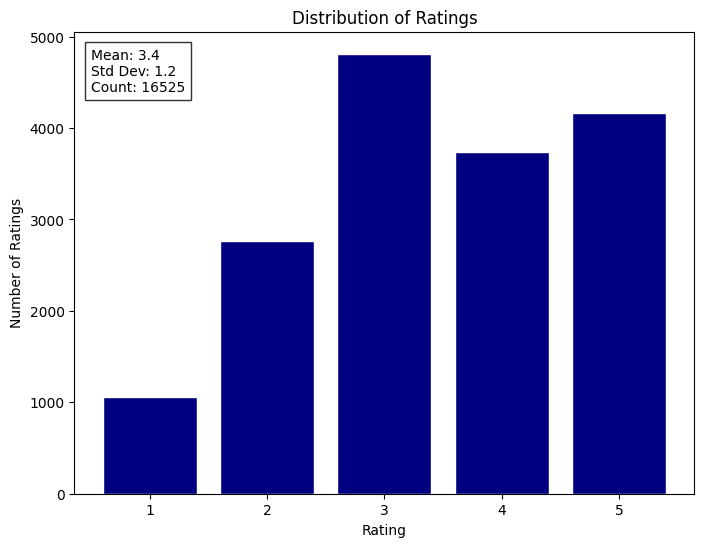

In [22]:
nonzero_ratings = user_rating_matrix[user_rating_matrix != 0]
bins = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
plt.figure(figsize=(8, 6))
plt.hist(nonzero_ratings, bins=bins, edgecolor='white', color='#000080', rwidth=0.8)
plt.xticks([1, 2, 3, 4, 5])  
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

mean_rating = np.mean(nonzero_ratings)
std_rating = np.std(nonzero_ratings)
count_nonzero = len(nonzero_ratings)
textstr = f"Mean: {mean_rating:.1f}\nStd Dev: {std_rating:.1f}\nCount: {count_nonzero:.0f}"
plt.gca().text(0.5, 4400, textstr, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

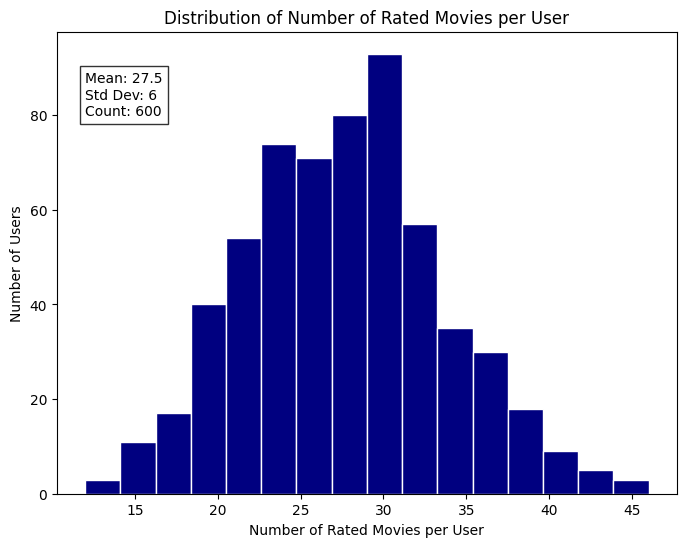

In [23]:
# Distribution of Number of Rated Movies per User
user_activity = np.count_nonzero(user_rating_matrix, axis=1)
plt.figure(figsize=(8, 6))
plt.hist(user_activity, bins='auto', edgecolor='white', color='#000080')
plt.title("Distribution of Number of Rated Movies per User")
plt.xlabel("Number of Rated Movies per User")
plt.ylabel("Number of Users")

mean_rating = np.mean(user_activity)
std_rating = np.std(user_activity)
count_nonzero = len(user_activity)
textstr = f"Mean: {mean_rating:.1f}\nStd Dev: {std_rating:.0f}\nCount: {count_nonzero:.0f}"
plt.gca().text(12, 80, textstr, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

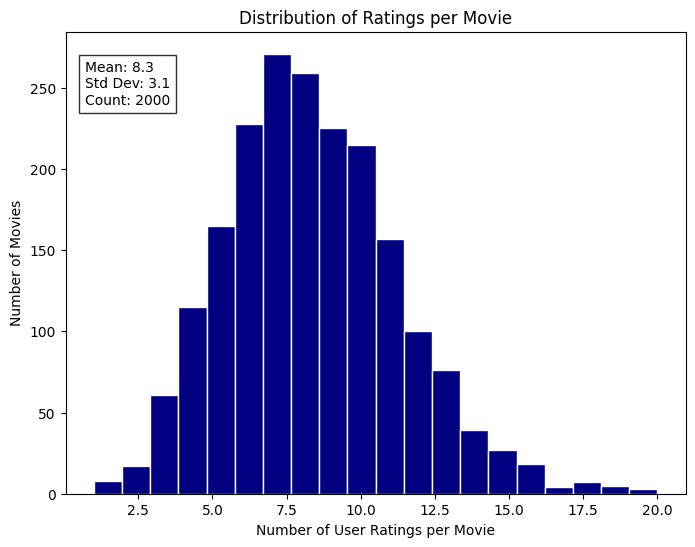

In [24]:
#Distribution of Ratings per Movie
movie_popularity = np.count_nonzero(user_rating_matrix, axis=0)
plt.figure(figsize=(8, 6))
plt.hist(movie_popularity, bins=20, edgecolor='white', color='#000080')
plt.title("Distribution of Ratings per Movie")
plt.xlabel("Number of User Ratings per Movie")
plt.ylabel("Number of Movies")

mean_rating = np.mean(movie_popularity)
std_rating = np.std(movie_popularity)
count_nonzero = len(movie_popularity)
textstr = f"Mean: {mean_rating:.1f}\nStd Dev: {std_rating:.1f}\nCount: {count_nonzero:.0f}"
plt.gca().text(0.7, 240, textstr, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.show()

C:\Users\anton\AppData\Local\Temp\ipykernel_27316\1009954954.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  genre_sums = g_df.sum(axis=1)


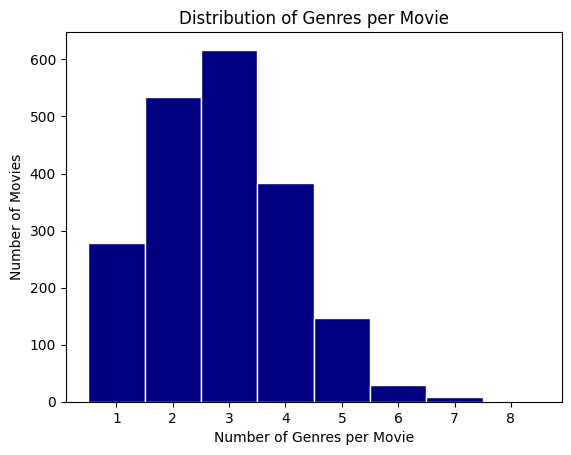

In [25]:
# Calculate the sum of genres per movie
genre_sums = g_df.sum(axis=1)

# Create bin edges so each integer is centered in its own bin
bins = np.arange(genre_sums.min(), genre_sums.max() + 2) - 0.5

# Plot the histogram
plt.hist(genre_sums, bins=bins, edgecolor='white', color='#000080')
plt.title("Distribution of Genres per Movie")
plt.xlabel("Number of Genres per Movie")
plt.ylabel("Number of Movies")

# Ensure x-ticks show every integer in range
plt.xticks(range(int(genre_sums.min()), int(genre_sums.max()) + 1))

plt.show()


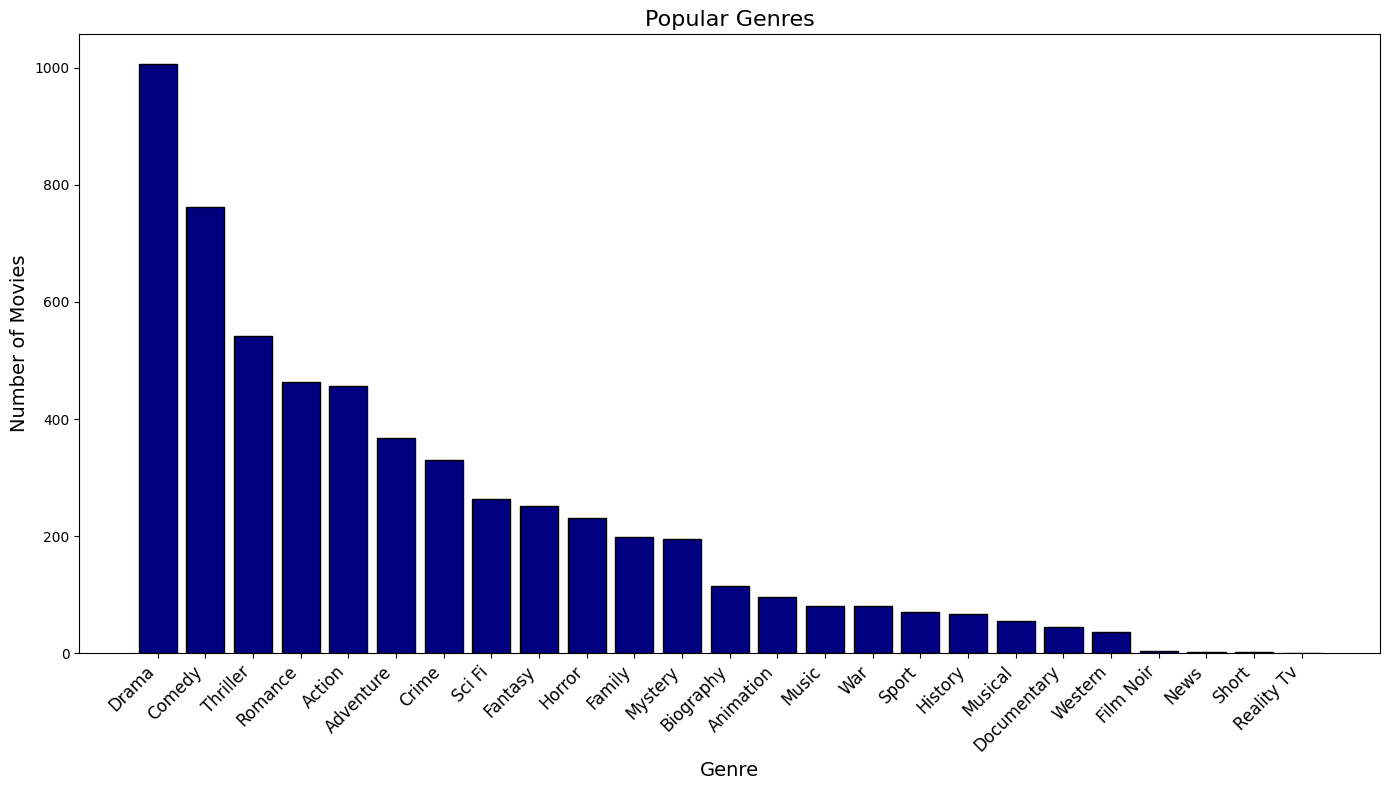

In [26]:
genre_sums = g_df.drop(columns='movie_title').sum(axis=0)
genre_labels = [
    genre.replace('genre_', '').replace('-', ' ').title() for genre in genre_sums.index
]
#clean and sort
genre_sums_clean = pd.Series(genre_sums.values, index=genre_labels)
genre_sums_sorted = genre_sums_clean.sort_values(ascending=False)
#plot
plt.figure(figsize=(14, 8))
bars = plt.bar(
    genre_sums_sorted.index,
    genre_sums_sorted.values,
    edgecolor='black',
    color = '#000080' #navy bluw
)
plt.title('Popular Genres', fontsize=16)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Number of Movies', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.tight_layout()
plt.show()

### Train Test Split

In [27]:
r_df_user_index = r_df.set_index('User', inplace=False) # setting the index to the user column
nonzero_ratings = r_df_user_index.stack().reset_index() # making the dataframe "long" instead of a matrix
nonzero_ratings.columns = ['User', 'Movie', 'Rating']
nonzero_ratings = nonzero_ratings[nonzero_ratings['Rating'] != 0.0]

#make the split
train, test = train_test_split(nonzero_ratings, test_size=0.05, random_state=21) # data is so sparse that we need as much data as possible for training 

#make the data to a matrix again
user_movie_matrix_train = (
    train.pivot(index='User', columns='Movie', values='Rating')
         .reindex(index=r_df_user_index.index,  # original users
                  columns=r_df_user_index.columns) # original columns
)

#fill nan values with 0 again
# user_movie_matrix_train = user_movie_matrix_train.fillna(0)

user_movie_matrix_train.head(10)


,The Net,Happily N'Ever After,Tomorrowland,American Hero,Das Boot,Final Destination 3,Licence to Kill,The Hundred-Foot Journey,The Matrix,Creature,...,The Martian,Micmacs,Solomon and Sheba,In the Company of Men,Silent House,Big Fish,Get Real,Trading Places,DOA: Dead or Alive,Hey Arnold! The Movie
User,,,,,,,,,,,,,,,,,,,,,
Vincent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Edgar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Addilyn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marlee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Javier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marcus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rosalie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Giovanni,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Collaborative filtering

In [28]:
#USER BASED COLLABORATIVE FILTERING
user_means = np.nanmean(user_movie_matrix_train, axis=1, keepdims=True) # Compute mean ratings
user_movie_matrix_centered = user_movie_matrix_train - user_means # Center the ratings
user_movie_matrix_centered = user_movie_matrix_centered.fillna(0) # Fill NaN 

# Calculate cosine similarity
dot_product = user_movie_matrix_centered @ user_movie_matrix_centered.T
norms = np.linalg.norm(user_movie_matrix_centered, axis=1) # Cosine similarity requires dividing by the magnitudes of the vectors to ensure that similarity depends only on the direction of the ratings patterns in preferences, not their absolute values
cosine_similarity_matrix = dot_product / np.outer(norms, norms) # This divides the dot product by the product of the norms for each pair of users.]


In [29]:
#MOVIE BASED COLLABORATIVE FILTERING
movie_means = np.nanmean(user_movie_matrix_train, axis=0, keepdims=True) 
user_movie_matrix_center = user_movie_matrix_train - movie_means 
user_movie_matrix_center = user_movie_matrix_train.fillna(0) 

# Calculate cosine similarity
dot_product = user_movie_matrix_center.T @ user_movie_matrix_center
norms = np.linalg.norm(user_movie_matrix_center, axis=0) 
cosine_similarity_matrix_movie = dot_product / np.outer(norms, norms)
# cosine_similarity_matrix_movie.head(10)

In [30]:
# MAKE A DICT WITH THE GENRES A USER WATHCES
g_df_movie_index = g_df.set_index('movie_title', inplace=False)

user_genre_dict = {}
for u,m,r in nonzero_ratings.values: # maybe also look at the ratings to improve the recomendations
    movie_ratings = g_df_movie_index.loc[m]
    selected_genres = movie_ratings[movie_ratings == 1]

    if u not in user_genre_dict:
        user_genre_dict[u] = {}

    for genre in selected_genres.index:
        if genre not in user_genre_dict[u]:
            user_genre_dict[u][genre] = 1 
        else:
            user_genre_dict[u][genre] += 1

# print(user_genre_dict)

# sort the dict by genre count
for user, genres_dict in user_genre_dict.items():
    sorted_genres = dict(sorted(genres_dict.items(), key=lambda item: item[1], reverse=True))
    user_genre_dict[user] = sorted_genres
print(user_genre_dict)


{'Vincent': {'genre_drama': 28, 'genre_romance': 16, 'genre_action': 14, 'genre_thriller': 12, 'genre_comedy': 10, 'genre_fantasy': 8, 'genre_adventure': 7, 'genre_crime': 5, 'genre_sci-fi': 5, 'genre_mystery': 3, 'genre_music': 2, 'genre_biography': 2, 'genre_history': 1, 'genre_war': 1, 'genre_animation': 1, 'genre_family': 1, 'genre_sport': 1, 'genre_horror': 1, 'genre_musical': 1}, 'Edgar': {'genre_drama': 19, 'genre_romance': 9, 'genre_thriller': 8, 'genre_comedy': 7, 'genre_crime': 5, 'genre_sci-fi': 4, 'genre_fantasy': 3, 'genre_horror': 3, 'genre_musical': 3, 'genre_adventure': 3, 'genre_action': 3, 'genre_music': 2, 'genre_western': 2, 'genre_animation': 2, 'genre_mystery': 2, 'genre_war': 2, 'genre_family': 1, 'genre_history': 1, 'genre_documentary': 1, 'genre_biography': 1, 'genre_sport': 1}, 'Addilyn': {'genre_comedy': 21, 'genre_drama': 16, 'genre_thriller': 11, 'genre_horror': 8, 'genre_crime': 7, 'genre_action': 7, 'genre_romance': 7, 'genre_adventure': 6, 'genre_fantasy

In [31]:
#CREATE USER AND  MOVIE BIASES DICTS
global_avg = np.nanmean(user_movie_matrix_train.values)
user_means = np.nanmean(user_movie_matrix_train.values, axis=1)
movie_means = np.nanmean(user_movie_matrix_train.values, axis=0)

#create dicts
user_biases = {}
for index, user in enumerate(user_movie_matrix_train.index):
    user_mean = user_means[index]     
    bias = user_mean - global_avg        
    user_biases[user] = bias

movie_biases = {}
for index, movie in enumerate(user_movie_matrix_train.columns):
    movie_mean = movie_means[index]      
    bias = movie_mean - global_avg        
    movie_biases[movie] = bias


In [32]:


def get_similar_users(user):
    row = cosine_similarity_matrix[user]
    row = row.sort_values(ascending=False)
    row = row.drop(user)
    row = row [row > 0.01] # only return positive similarities
    return row

def get_similar_movies(movie):
    row = cosine_similarity_matrix_movie[movie]
    row = row.sort_values(ascending=False)
    row = row [row > 0.1] # only return positive similarities
    return row


def predict_rating_avg_and_genres(user, movie):
    movie_genres = g_df_movie_index.loc[movie]
    current_genres = movie_genres[movie_genres == 1].index

    user_bias = user_biases[user] * 0.6
    movie_bias = movie_biases[movie] * 0

    i = 3
    match = 0
    user_genres = user_genre_dict[user]
    sum_counts = sum(user_genres.values())

    for genre, count in user_genre_dict[user].items():
        if genre in current_genres:
            match += 2.5 * count / sum_counts
        else :
            match -= 2.5 * count / sum_counts
        i -= 1
        if i <= 0:
            break
    return global_avg + match + user_bias + movie_bias

def predict_rating_CF(user, movie): # the data is too sparse for this! Often we only get 1 or 2 similar users with rating for the movie
    similar_users = get_similar_users(user)
    similar_movies = get_similar_movies(movie)

    similar_ratings = []
    for m, ms in similar_movies.items(): #ms = movie similarity
        for u, us in similar_users.items(): #us = user similarity
            rating = r_df_user_index.loc[u,m]      
            if rating > 0: # only include users with positive ratings
                similar_ratings.append((us*ms, rating))
        if len(similar_ratings) > 50: # choose the maximum number of similar users to use for prediction 
            break

    numerator = sum(similarity * rating for similarity, rating in similar_ratings)
    denominator = sum(similarity for similarity, _ in similar_ratings)

    if denominator == 0:
        return np.nan
    else:
        return numerator / denominator

In [33]:
#testing with the test data 
def calculate_rmse(model):
    errors = []
    for u, m, accual_rating in test.values:
        predicted_rating = model(u, m)
        if not np.isnan(predicted_rating):
            error = (accual_rating - predicted_rating) ** 2
            errors.append(error)
    rmse = np.sqrt(np.mean(errors))
    print("model:", model.__name__, "  RMSE:", rmse)
    return rmse
    
rmse_avg_genres = calculate_rmse(predict_rating_avg_and_genres)
rmse_CF = calculate_rmse(predict_rating_CF)

model: predict_rating_avg_and_genres   RMSE: 1.0703606061200532
model: predict_rating_CF   RMSE: 1.1828937436251505


In [34]:
print(predict_rating_avg_and_genres('Keira', 'Tomorrowland')) 
print(predict_rating_CF('Keira', 'Tomorrowland'))

2.143175275730922
2.9115752156550037
